# 10 · Robustness and temporal stability
Tests: feature-family removal, weight perturbation, artifact neutralisation, alternative typology datasets,
threshold changes (notebook 09), segments (notebook 04), early vs late test weeks, and feature drift (PSI).

In [1]:
import sys, json, sqlite3
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import config
pd.set_option("display.width", 180); pd.set_option("display.max_columns", 30); pd.set_option("display.precision", 4)
T = lambda name: pd.read_csv(config.TABLES_DIR / f"{name}.csv")
KM = json.loads((config.TABLES_DIR / "key_metrics.json").read_text())
con = sqlite3.connect(config.DB_PATH)
def show(fig_name, width=11):
    img = plt.imread(config.FIGURES_DIR / f"{fig_name}.png")
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w)); ax.imshow(img); ax.axis("off")
print("outputs loaded from", config.TABLES_DIR.relative_to(ROOT))

outputs loaded from outputs/tables


In [2]:
T("robustness_feature_removal")

,scenario,alerts,alert_precision,account_recall,pr_auc,roc_auc,precision_top5pct,base_rate
0,full framework,215,0.8651,0.1407,0.4573,0.7534,0.6875,0.0919
1,without transaction features,215,0.8651,0.1407,0.4572,0.7534,0.6875,0.0919
2,without velocity features,188,0.6383,0.0832,0.2523,0.6916,0.3470,0.0919
3,without behavioral features,342,0.8421,0.2181,0.4302,0.7854,0.6918,0.0919
4,without aml_pattern features,217,0.8525,0.1395,0.4547,0.7533,0.6918,0.0919
5,without network features,218,0.8670,0.1430,0.4597,0.7547,0.6875,0.0919


In [3]:
wp = T("robustness_weight_perturbation")
print(wp.head(2).to_string()); print(wp[wp.variant.str.startswith("random")].pr_auc.describe().round(4))

                                        variant  pr_auc  roc_auc  precision_top5pct
0                                fitted weights  0.4575   0.7534             0.6875
1  equal weights (mean of fitted, all features)  0.2073   0.6609             0.2931
count    200.0000
mean       0.4559
std        0.0027
min        0.4434
25%        0.4548
50%        0.4565
75%        0.4577
max        0.4595
Name: pr_auc, dtype: float64


### Artifact-neutralised scenario (duplicates removed, amounts floored at 100)

In [4]:
T("robustness_artifact_neutralised_alerts")[["approach", "alerts", "alert_precision", "account_recall"]]

,approach,alerts,alert_precision,account_recall
0,B1 Amount threshold,481,0.1081,0.0528
1,B2 Amount + velocity,700,0.3200,0.1512
2,B3 Behavioural anomaly,315,0.5365,0.1067
3,B4 Network / AML patterns,978,0.3763,0.1477
4,B5a Integrated rules (>=2 families),250,0.6800,0.0950
5,B5b Integrated risk score (top 1%),170,0.7765,0.0680


In [5]:
T("robustness_artifact_neutralised_ranking")[["approach", "pr_auc", "roc_auc", "precision_top5pct"]]

,approach,pr_auc,roc_auc,precision_top5pct
0,B1 Amount threshold,0.1114,0.5554,0.1250
1,B2 Amount + velocity,0.2848,0.7043,0.3987
2,B5a Integrated rules (>=2 families),0.2483,0.6982,0.3664
3,B5b Integrated risk score (top 1%),0.2714,0.7108,0.3815


### Alternative AMLSim samples (fan-in only, cycle only)

In [6]:
T("robustness_datasets")

,dataset,typologies,alerts,alert_precision,account_recall,pr_auc,roc_auc,precision_top5pct,base_rate,b2_alert_precision,weights
0,combined (primary),200 fan-in + 200 cycle,215,0.8651,0.1407,0.4573,0.7534,0.6875,0.0919,0.4064,NaN
1,fanin,200 fan-in,177,0.4802,0.1521,0.2976,0.7367,0.3737,0.0483,0.1960,"{'max_amt': 0.0, 'n_tx': 0.681, 'velocity_ratio': 0.113, 'new_cp': 0.0, 'rapid_movement': 0.0, 'cycle_count': 0.0, 'fan_in_28': 0.0, 'fan_out_28': 0.0, 'pagerank_28': 0.0}"
2,cycle,200 cycle,221,0.6290,0.2018,0.3349,0.7654,0.3944,0.0486,0.2736,"{'max_amt': 0.0, 'n_tx': 0.713, 'velocity_ratio': 0.116, 'new_cp': 0.0, 'rapid_movement': 0.0, 'cycle_count': 0.0, 'fan_in_28': 0.0, 'fan_out_28': 0.0, 'pagerank_28': 0.0}"


### Temporal stability and drift

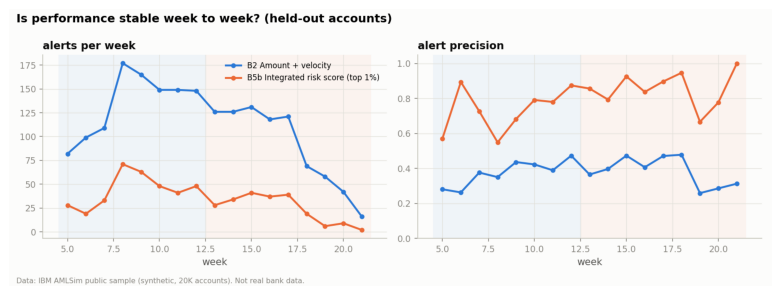

,window,approach,alerts,alert_precision,account_recall,base_rate
0,early test (weeks 13-16),B1 Amount threshold,290,0.1138,0.0399,0.0940
1,early test (weeks 13-16),B2 Amount + velocity,501,0.4112,0.1911,0.0940
2,early test (weeks 13-16),B3 Behavioural anomaly,258,0.6047,0.1415,0.0940
3,early test (weeks 13-16),B4 Network / AML patterns,566,0.3534,0.1088,0.0940
4,early test (weeks 13-16),B5a Integrated rules (>=2 families),209,0.7177,0.1306,0.0940
5,early test (weeks 13-16),B5b Integrated risk score (top 1%),140,0.8571,0.1040,0.0940
6,late test (weeks 17-21),B1 Amount threshold,198,0.1162,0.0254,0.1117
7,late test (weeks 17-21),B2 Amount + velocity,306,0.3987,0.1171,0.1117
8,late test (weeks 17-21),B3 Behavioural anomaly,109,0.8073,0.0889,0.1117
9,late test (weeks 17-21),B4 Network / AML patterns,407,0.3980,0.0973,0.1117


In [7]:
show("fig13_weekly_stability")
T("robustness_early_vs_late")[["window", "approach", "alerts", "alert_precision", "account_recall", "base_rate"]]

In [8]:
T("feature_drift_psi").sort_values("psi_dev_vs_test", ascending=False)

,feature,psi_dev_vs_test
10,hist_n_tx,1.9780
8,pagerank_28,0.8734
2,velocity_ratio,0.2659
11,risk_score,0.1572
7,fan_out_28,0.0440
3,new_cp,0.0244
6,fan_in_28,0.0131
9,n_cp,0.0110
1,n_tx,0.0075
0,max_amt,0.0029


**Caveat:** the simulation covers 149 daily steps (about 21 weeks); this is enough to compare a development and
a test period but not to assess long-term drift, seasonality or typology evolution.